# Understanding ensemble dephasing

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erf, erfc, erfi
import scipy.signal

In [2]:
# Main parameters
omega0 = 2 * np.pi # central frequency
decay_rate = 0.2
# Gabor_T = 2.0
omega_min = omega0 - 20 * decay_rate
omega_max = omega0 + 20 * decay_rate
number_of_samples = 51

# Plotting ranges
t_max = 50.
time_range = np.linspace(0, t_max, 500)
omega_range = np.linspace(omega_min, omega_max, 500)
tau_range = np.linspace(0, t_max, 500)
# gabor_omega_range = np.linspace(omega_min, omega_max, 100)

In [3]:
def original_signal_time_domain(time, omega0, decay_rate):
    r"""
    Computes $\Theta(t) e^{-(\gamma t)^2} \sin(\omega_0 t)$
    """
    return np.heaviside(time, 1) * np.exp(-(decay_rate * time)**2) * np.sin(omega0 * time)

def original_signal_frequency_domain(omega, omega0, decay_rate):
    r"""
    Computes $\frac{\sqrt{\pi} \left(-e^{-\frac{(\omega - \omega_0)^2}{4 \gamma^2}}
      (-i + \mathrm{Erfi}\left[\frac{\omega - \omega_0}{2 \gamma}\right]) +
      e^{-\frac{(\omega + \omega_0)^2}{4 \gamma^2}} (-i + \mathrm{Erfi}
      \left[\frac{\omega + \omega_0}}{2 \gamma}\right])\right)}{4 \gamma}$
    """
    gamma = decay_rate

    exp_arg1 = -((omega - omega0) / (2 * gamma))**2
    exp_arg2 = -((omega + omega0) / (2 * gamma))**2

    if np.isscalar(omega):
      if exp_arg1 >= -100:
        term1 = np.exp(exp_arg1) * (-1j + erfi((omega - omega0) / (2 * gamma)))
      else:
        term1 = 0
      if exp_arg2 >= -100:
        term2 = np.exp(exp_arg2) * (-1j + erfi((omega + omega0) / (2 * gamma)))
      else:
        term2 = 0
    else:
      term1 = np.zeros(omega.shape, dtype=complex)
      s = (exp_arg1 >= -100)
      term1[s] = np.exp(exp_arg1[s]) * (-1j + erfi((omega[s] - omega0) / (2 * gamma)))
      term2 = np.zeros(omega.shape, dtype=complex)
      s = (exp_arg2 >= -100)
      term2[s] = np.exp(exp_arg2[s]) * (-1j + erfi((omega[s] + omega0) / (2 * gamma)))

    return (np.sqrt(np.pi) / (4 * gamma)) * (term2 - term1)


def original_signal_Gabor_transform(tau, omega, omega0, decay_rate, Gabor_T):
    r"""
    Computes $\frac{\exp\left[ - \frac{4 \gamma^2 \tau^2 -
      4 i \tau (\omega - \omega_{\mathrm{0}}) +
      T^2 (\omega + \omega_{\mathrm{0}})^2}{4 + 4 T^2 \gamma^2} \right]
      \sqrt{\pi} T \left(- \exp\left(
        \frac{T^2 \omega \omega_{\mathrm{0}}}{1 + T^2 \gamma^2} \right)
        \left( -i + \mathrm{erfi}\left[ \frac{-2 i \tau + T^2 (\omega -
         \omega_{\mathrm{0}})}{2 T \sqrt{1 + T^2 \gamma^2}} \right] \right) +
      \exp\left( \frac{2 i \tau \omega_{\mathrm{0}}}{1 + T^2 \gamma^2} \right)
      \left( -i + \mathrm{erfi}\left[ \frac{-2 i \tau +
       T^2 (\omega + \omega_{\mathrm{0}})}{2 T \sqrt{1 + T^2 \gamma^2}} \right]
     \right) \right)}{4 \sqrt{1 + T^2 \gamma^2}}$
    """
    gamma = decay_rate
    T = Gabor_T

    def complex_erfi(z):
        return -1j * erf(1j * z)

    sqrt_factor = np.sqrt(1 + T**2 * gamma**2)

    arg_erfi1 = (-2j * tau + T**2 * (omega - omega0)) / (2 * T * sqrt_factor)
    arg_erfi2 = (-2j * tau + T**2 * (omega + omega0)) / (2 * T * sqrt_factor)

    # Terms with combined exponents to avoid overflow
    exp_arg1 = (-4 * gamma**2 * tau**2 + 4j * tau * (omega - omega0) -
                T**2 * (omega - omega0)**2) / (4 * (1 + T**2 * gamma**2))
    term1 = -np.exp(exp_arg1) * (-1j + complex_erfi(arg_erfi1))

    exp_arg2 = (-4 * gamma**2 * tau**2 + 4j * tau * (omega + omega0) -
                T**2 * (omega + omega0)**2) / (4 * (1 + T**2 * gamma**2))
    term2 = np.exp(exp_arg2) * (-1j + complex_erfi(arg_erfi2))

    numerator = np.sqrt(np.pi) * T * (term1 + term2)
    denominator = 4 * sqrt_factor

    return numerator / denominator

def discretized_signal_time_domain(time, amplitudes, omega_array):
    time = np.atleast_1d(time)
    res = np.sum(np.real(amplitudes[:, np.newaxis] * np.exp(-1j * omega_array[:, np.newaxis] * time)), axis=0)
    return res.squeeze() / np.pi

def discretized_signal_Gabor_transform(tau, omega, amplitudes, omega_array, Gabor_T):
    r"""
    Computes $\frac{T}{2 \sqrt{\pi}} \sum_n a_n \exp\left(i \tau (\Omega - \Omega_{\mathrm{array}}) -
      \frac{1}{4} T^2 (\Omega - \Omega_{\mathrm{array}})^2\right)$
    """
    T = Gabor_T
    total_transform = np.zeros_like(omega, dtype=np.complex128)

    for n in range(len(omega_array)):
        delta_omega = omega - omega_array[n]
        exp_term = np.exp(-0.25 * (delta_omega * T)**2 +
                          1j * tau * delta_omega)
        total_transform += amplitudes[n] * 0.5 * exp_term * T / np.sqrt(np.pi)

    return total_transform

def original_autocorrelation_function(tau, omega0, gamma):
    r"""
    Calculates the autocorrelation function based on the analytical expression.

    $$
    S(\tau) = \frac{\sqrt{\frac{\pi}{2}} e^{-\frac{\gamma^4 \tau^2 + \omega_\mathrm{L}^2}{2 \gamma^2}}
        \left(\text{erf}\left(\frac{\gamma^2 |\tau| - i \omega_\mathrm{L}}{\sqrt{2} \gamma}
        \right) + \text{erf}\left(\frac{\gamma^2 |\tau| + i \omega_\mathrm{L}}{\sqrt{2} \gamma }\right)+
        2 e^{\frac{\omega_\mathrm{L}^2}{2 \gamma^2}}
        \text{erfc}\left(\frac{\gamma |\tau| }{\sqrt{2}}\right)
        \cos(\omega_\mathrm{L} \tau) - 2\right)}{8 \gamma}
    $$
    """
    # Calculate the absolute value of tau once to reuse it
    abs_tau = np.abs(tau)
    
    # Pre-calculate common denominator terms
    sqrt2_gamma = np.sqrt(2) * gamma
    gamma_sq = gamma**2
    
    # Term 1: Exponential prefix
    exp_prefix = np.exp(-((omega0**2 + gamma**4 * abs_tau**2) / (2 * gamma_sq)))
    
    # Term 2: Square root constant
    sqrt_pi_half = np.sqrt(np.pi / 2)
    
    # Term 3: The large bracket
    # Note: scipy.special.erf natively supports complex arguments
    erf_arg1 = (-1j * omega0 + gamma_sq * abs_tau) / sqrt2_gamma
    erf_arg2 = ( 1j * omega0 + gamma_sq * abs_tau) / sqrt2_gamma
    
    erfc_term = 2 * np.exp(omega0**2 / (2 * gamma_sq)) * \
                np.cos(omega0 * abs_tau) * \
                erfc((gamma * abs_tau) / np.sqrt(2))
    
    bracket = -2 + erf(erf_arg1) + erf(erf_arg2) + erfc_term
    
    # Combine everything and divide by the denominator
    result = (exp_prefix * sqrt_pi_half * bracket) / (8 * gamma)
    
    return result.real


def discretized_autocorrelation_function(time, amplitudes, omega_array):
    signal = discretized_signal_time_domain(time, amplitudes, omega_array)
    N_t = len(time)
    result = np.zeros((2*N_t-1, 2))
    dt = (time[-1] - time[0]) / (N_t - 1)
    result[:, 0] = dt * np.arange(-(N_t-1), N_t) # tau
    result[:, 1] = dt * scipy.signal.correlate(signal, signal, mode='full', method='auto')
    return result


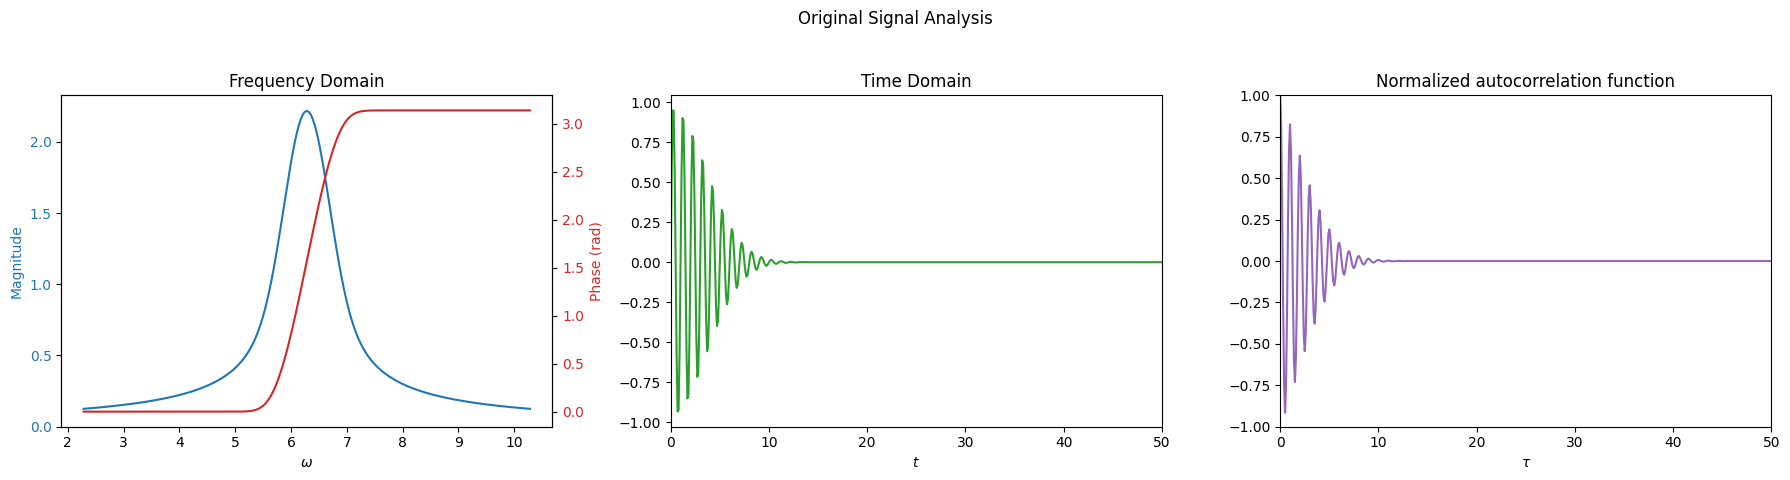

In [4]:
# --- Figure 1: Continuous Signal ---
fig1, axes1 = plt.subplots(1, 3, figsize=(18, 5))
fig1.suptitle('Original Signal Analysis')

# Plot 1.1: Frequency Domain
ax1_abs = axes1[0]
ax1_phase = ax1_abs.twinx()

freq_signal = original_signal_frequency_domain(omega_range, omega0, decay_rate)
abs_freq = np.abs(freq_signal)
phase_freq = np.angle(freq_signal)

color_abs = 'tab:blue'
color_phase = 'tab:red'

ax1_abs.plot(omega_range, abs_freq, color=color_abs, label='Magnitude')
ax1_abs.set_ylim(0, 1.05*np.max(abs_freq))
ax1_phase.plot(omega_range, phase_freq, color=color_phase, label='Phase')

ax1_abs.set_xlabel(r'$\omega$')
ax1_abs.set_ylabel('Magnitude', color=color_abs)
ax1_phase.set_ylabel('Phase (rad)', color=color_phase)
ax1_abs.tick_params(axis='y', labelcolor=color_abs)
ax1_phase.tick_params(axis='y', labelcolor=color_phase)
ax1_abs.set_title('Frequency Domain')

# Plot 1.2: Time Domain
time_signal = original_signal_time_domain(time_range, omega0, decay_rate)
axes1[1].plot(time_range, time_signal, color='tab:green')
axes1[1].set_xlabel(r'$t$')
axes1[1].set_xlim(0, time_range[-1])
# axes1[1].set_ylabel('Signal Amplitude')
axes1[1].set_title('Time Domain')

# Plot 1.3: Autocorrelation function
original_autocorrelation = original_autocorrelation_function(tau_range, omega0, decay_rate)
axes1[2].plot(tau_range, original_autocorrelation / np.max(original_autocorrelation), color='tab:purple')
axes1[2].set_xlabel(r'$\tau$')
axes1[2].set_xlim(0, tau_range[-1])
axes1[2].set_ylim(-1, 1)
# axes1[2].set_ylabel('Signal Amplitude')
axes1[2].set_title('Normalized autocorrelation function')


# # Plot 1.3: Gabor Transform
# tau_grid, omega_grid = np.meshgrid(tau_range, gabor_omega_range)
# gabor_transform = original_signal_Gabor_transform(tau_grid, omega_grid, omega0, decay_rate, Gabor_T)
# gabor_intensity = np.abs(gabor_transform)**2
# 
# im = axes1[2].pcolormesh(tau_grid, omega_grid, gabor_intensity, shading='auto', cmap='viridis')
# axes1[2].set_xlabel(r'$\tau$')
# axes1[2].set_ylabel(r'Frequency ($\omega$)')
# axes1[2].set_title('Gabor Transform (Spectrogram)')
# fig1.colorbar(im, ax=axes1[2], label='Intensity')

fig1.tight_layout(rect=[0, 0.03, 1, 0.95])

# Store axis limits for Figure 2
ax1_abs_lim = ax1_abs.get_ylim()
ax1_phase_lim = ax1_phase.get_ylim()
ax1_time_lim = axes1[1].get_ylim()

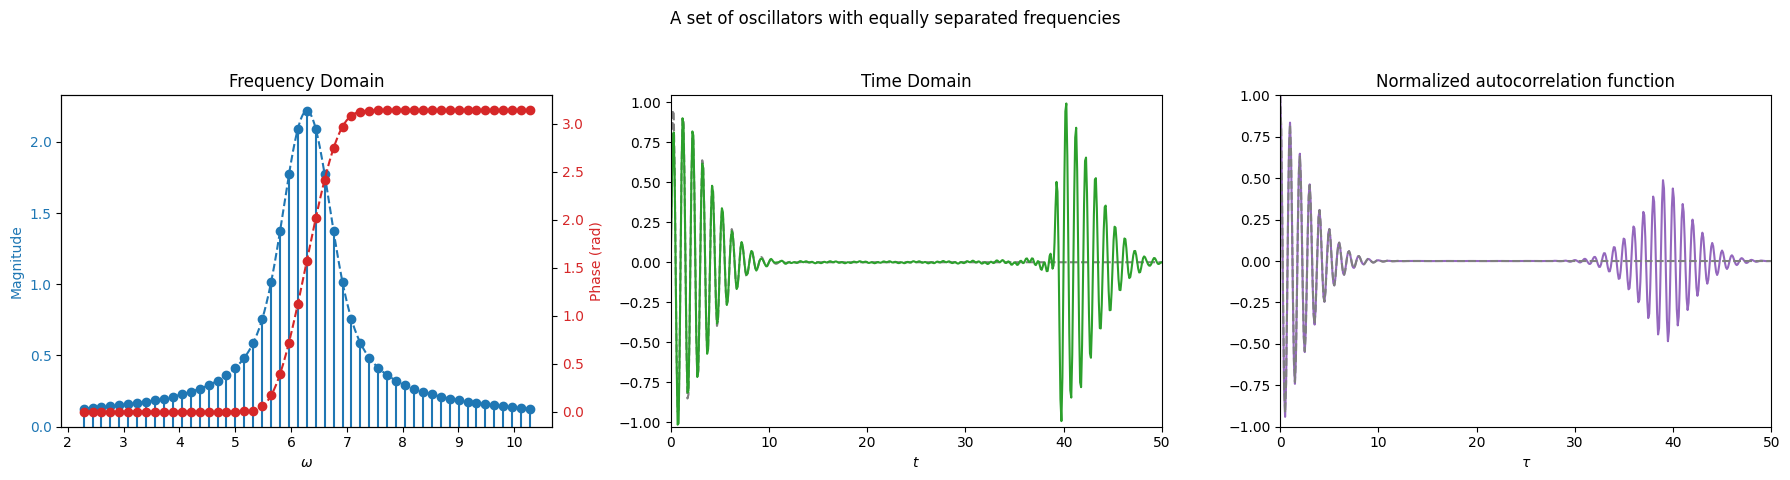

In [5]:
# --- Figure 2: A set of oscillators with equally separated frequencies ---
fig2, axes2 = plt.subplots(1, 3, figsize=(18, 5))
fig2.suptitle('A set of oscillators with equally separated frequencies')

omega_array = np.linspace(omega_min, omega_max, number_of_samples)
omega_step = (omega_max - omega_min) / (number_of_samples - 1)

# --- Calculate amplitudes for discretized signal ---
amplitudes = original_signal_frequency_domain(omega_array, omega0, decay_rate)

# Plot 2.1: Frequency Domain (Discretized)
ax2_abs = axes2[0]
ax2_phase = ax2_abs.twinx()

# Original signal as dashed lines
ax2_abs.plot(omega_range, abs_freq, color=color_abs, linestyle='--', label='Original Magnitude')
ax2_phase.plot(omega_range, phase_freq, color=color_phase, linestyle='--', label='Original Phase')

# Discretized amplitudes
markerline, stemlines, baseline = ax2_abs.stem(omega_array, np.abs(amplitudes), basefmt=" ", label='Sampled Magnitude')
plt.setp(stemlines, 'color', color_abs)
plt.setp(markerline, 'color', color_abs)

ax2_phase.plot(omega_array, np.angle(amplitudes), 'o', color=color_phase, label='Sampled Phase')

ax2_abs.set_xlabel(r'$\omega$')
ax2_abs.set_ylabel('Magnitude', color=color_abs)
ax2_phase.set_ylabel('Phase (rad)', color=color_phase)
ax2_abs.tick_params(axis='y', labelcolor=color_abs)
ax2_phase.tick_params(axis='y', labelcolor=color_phase)
ax2_abs.set_title('Frequency Domain')
ax2_abs.set_ylim(ax1_abs_lim)
ax2_phase.set_ylim(ax1_phase_lim)

# Plot 2.2: Time Domain
axes2[1].plot(time_range, time_signal, linestyle='--', color='tab:grey')
disc_time_signal = discretized_signal_time_domain(time_range, amplitudes, omega_array)
disc_time_signal *= omega_step
axes2[1].plot(time_range, disc_time_signal, color='tab:green')
axes2[1].set_xlabel(r'$t$')
# axes2[1].set_ylabel('Signal Amplitude')
axes2[1].set_title('Time Domain')
axes2[1].set_ylim(ax1_time_lim)

# Plot 2.3: Autocorrelation
disc_autocorrelation = discretized_autocorrelation_function(time_range, amplitudes, omega_array)
X = disc_autocorrelation[:, 0]
Y = disc_autocorrelation[:, 1]
axes2[2].plot(X, Y / np.max(Y), color='tab:purple')
axes2[2].plot(tau_range, original_autocorrelation / np.max(original_autocorrelation), linestyle='--', color='tab:grey')
axes2[2].set_xlabel(r'$\tau$')
axes2[2].set_xlim(0, tau_range[-1])
axes1[2].set_ylim(-1, 1)
# axes2[2].set_ylabel('Signal Amplitude')
axes2[2].set_title('Normalized autocorrelation function')

# # Plot 2.3: Gabor Transform
# disc_gabor_transform = discretized_signal_Gabor_transform(tau_grid, omega_grid, amplitudes, omega_array, Gabor_T)
# disc_gabor_intensity = np.abs(omega_step * disc_gabor_transform)**2
# 
# im2 = axes2[2].pcolormesh(tau_grid, omega_grid, disc_gabor_intensity, shading='auto', cmap='viridis', vmin=np.min(gabor_intensity), vmax=np.max(gabor_intensity))
# axes2[2].set_xlabel(r'$\tau$')
# axes2[2].set_ylabel(r'Frequency ($\omega$)')
# axes2[2].set_title('Gabor Transform')
# fig2.colorbar(im2, ax=axes2[2], label='Intensity')

fig2.tight_layout(rect=[0, 0.03, 1, 0.95])

# Set same axis limits for comparison
for i in range(3):
    axes2[i].set_xlim(axes1[i].get_xlim())
axes2[0].set_ylim(axes1[0].get_ylim())
axes2[1].set_ylim(axes1[1].get_ylim())
axes2[2].set_ylim(axes1[2].get_ylim())

plt.show()

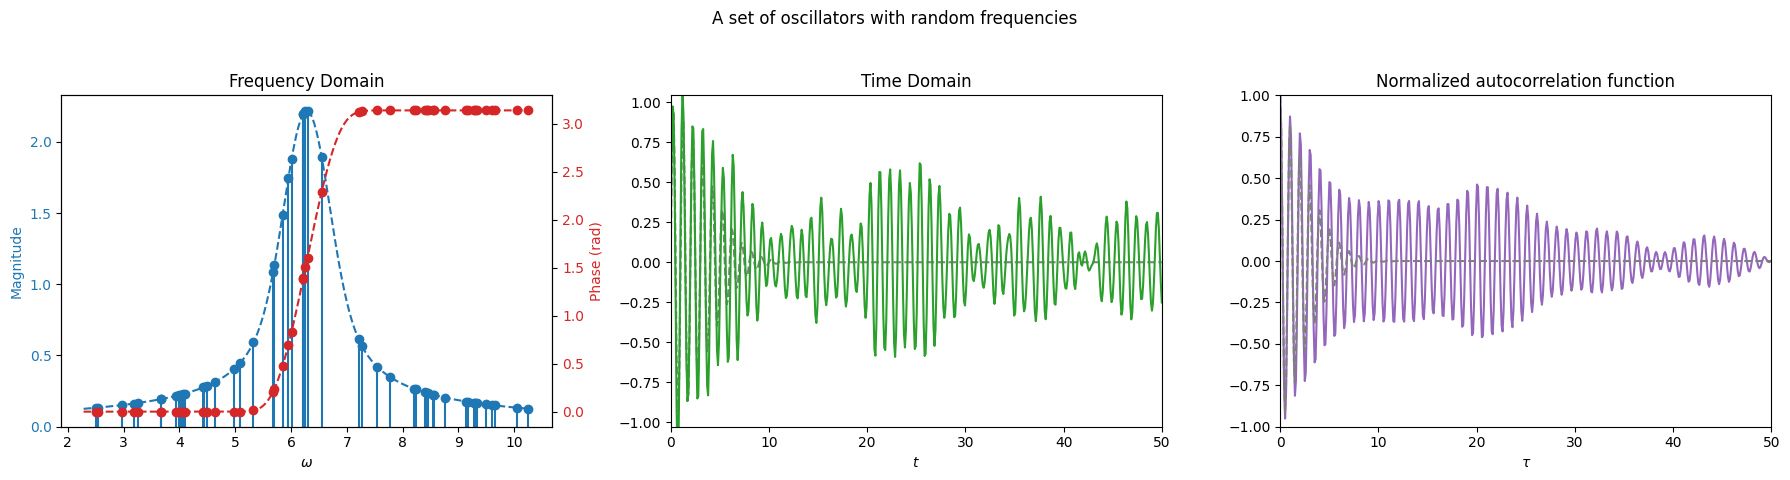

In [6]:
# --- Figure 3: A set of oscillators with random frequencies ---
fig3, axes3 = plt.subplots(1, 3, figsize=(18, 5))
fig3.suptitle('A set of oscillators with random frequencies')

omega_array = np.random.uniform(low=omega_min, high=omega_max,
                                  size=number_of_samples)
omega_step = (omega_max - omega_min) / (number_of_samples - 1)

# --- Calculate amplitudes for discretized signal ---
amplitudes = original_signal_frequency_domain(omega_array, omega0, decay_rate)

# Plot 3.1: Frequency Domain (Discretized)
ax3_abs = axes3[0]
ax3_phase = ax3_abs.twinx()

# Original signal as dashed lines
ax3_abs.plot(omega_range, abs_freq, color=color_abs, linestyle='--', label='Original Magnitude')
ax3_phase.plot(omega_range, phase_freq, color=color_phase, linestyle='--', label='Original Phase')

# Discretized amplitudes
markerline, stemlines, baseline = ax3_abs.stem(omega_array, np.abs(amplitudes), basefmt=" ", label='Sampled Magnitude')
plt.setp(stemlines, 'color', color_abs)
plt.setp(markerline, 'color', color_abs)

ax3_phase.plot(omega_array, np.angle(amplitudes), 'o', color=color_phase, label='Sampled Phase')

ax3_abs.set_xlabel(r'$\omega$')
ax3_abs.set_ylabel('Magnitude', color=color_abs)
ax3_phase.set_ylabel('Phase (rad)', color=color_phase)
ax3_abs.tick_params(axis='y', labelcolor=color_abs)
ax3_phase.tick_params(axis='y', labelcolor=color_phase)
ax3_abs.set_title('Frequency Domain')
ax3_abs.set_ylim(ax1_abs_lim)
ax3_phase.set_ylim(ax1_phase_lim)

# Plot 3.2: Time Domain
axes3[1].plot(time_range, time_signal, linestyle='--', color='tab:grey')
disc_time_signal = omega_step * discretized_signal_time_domain(time_range, amplitudes, omega_array)
axes3[1].plot(time_range, disc_time_signal, color='tab:green')
axes3[1].set_xlabel(r'$t$')
# axes3[1].set_ylabel('Signal Amplitude')
axes3[1].set_title('Time Domain')
axes3[1].set_ylim(ax1_time_lim)

# Plot 2.3: Autocorrelation
disc_autocorrelation = discretized_autocorrelation_function(time_range, amplitudes, omega_array)
X = disc_autocorrelation[:, 0]
Y = disc_autocorrelation[:, 1]
axes3[2].plot(X, Y / np.max(Y), color='tab:purple')
axes3[2].plot(tau_range, original_autocorrelation / np.max(original_autocorrelation), linestyle='--', color='tab:grey')
axes3[2].set_xlabel(r'$\tau$')
axes3[2].set_xlim(0, tau_range[-1])
axes1[2].set_ylim(-1, 1)
# axes3[2].set_ylabel('Signal Amplitude')
axes3[2].set_title('Normalized autocorrelation function')

# # Plot 3.3: Gabor Transform
# disc_gabor_transform = discretized_signal_Gabor_transform(tau_grid, omega_grid, amplitudes, omega_array, Gabor_T)
# disc_gabor_intensity = np.abs(omega_step * disc_gabor_transform)**2
# 
# im2 = axes3[2].pcolormesh(tau_grid, omega_grid, disc_gabor_intensity, shading='auto', cmap='viridis', vmin=np.min(gabor_intensity), vmax=np.max(gabor_intensity))
# axes3[2].set_xlabel(r'$\tau$')
# axes3[2].set_ylabel(r'Frequency ($\omega$)')
# axes3[2].set_title('Gabor Transform')
# fig3.colorbar(im2, ax=axes3[2], label='Intensity')

fig3.tight_layout(rect=[0, 0.03, 1, 0.95])

# Set same axis limits for comparison
for i in range(3):
    axes3[i].set_xlim(axes1[i].get_xlim())
axes3[0].set_ylim(axes1[0].get_ylim())
axes3[1].set_ylim(axes1[1].get_ylim())
axes3[2].set_ylim(axes1[2].get_ylim())

plt.show()